In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Pumpkin.metrics import KeyMetrics # internal tool for risk model evaluation 
from sklearn.metrics import auc

In [2]:
v4_test_select = pd.read_csv(f'./output/v4_test_select.csv')
v4_model_pred = pd.read_csv(f'./output/v4_y_test_pred1.csv')
v5_test_select = pd.read_csv(f'./output/v5_test_select.csv')
v5_model_pred = pd.read_csv(f'./output/v5_y_test_pred1.csv')

In [3]:
km_base = KeyMetrics(v4_test_select['ncat_infl_adj']/v5_test_select['ee'], # actual pp
        v5_test_select['p0_alxc_wo_cape_pred'], # predicted pp
        v5_test_select['ee'])

print(f'Baseline validation dataset has gini of ',km_base.gini())

km_v4 = KeyMetrics(v4_test_select['ncat_infl_adj']/v4_test_select['ee'], # actual pp
                v4_model_pred['y_test_pred1']/v4_test_select['ee'], # predicted pp
                v4_test_select['ee'])
print(f'Version 4 validation dataset has gini of ',km_v4.gini())

km_v5 = KeyMetrics(v5_test_select['ncat_infl_adj']/v5_test_select['ee'], # actual pp
                v5_model_pred['y_test_pred1']/v5_test_select['ee'], # predicted pp
                v5_test_select['ee'])
print(f'Version 5 validation dataset has gini of ',km_v5.gini())

Baseline validation dataset has gini of  0.2730884360923187
Version 4 validation dataset has gini of  0.27744165820690214
Version 5 validation dataset has gini of  0.28238978514963164


In [4]:
print(v4_test_select['ee'].describe())
print(v5_test_select['ee'].describe())

count    248953.000000
mean          0.946360
std           0.194047
min           0.002731
25%           0.999992
50%           0.999993
75%           0.999993
max           1.000000
Name: ee, dtype: float64
count    248953.000000
mean          0.946360
std           0.194047
min           0.002731
25%           0.999992
50%           0.999993
75%           0.999993
max           1.000000
Name: ee, dtype: float64


In [15]:
# enhance dual lift function
def dual_lift(df_dual, # dataframe name for the data to plot dual lift
            col_pp_act, # col name for actual pp, a string
            col_pp_pred1, # col name for predicted pp from model 1, a string
            col_pp_pred2, # col name for predicted pp from model 2, a string
            col_ee = 'ee', # col name for earned exposure
            n_bins = 20, # number of bins in chart
            fig_size = (6,3), 
            ctitle = 'dual lift', # chart title
            label1 = 'old model', # label for model1 pred
            label2 = 'new model', # label for model2 pred
            ):
  """
  plot dual lift, and return the underlying data as a dataframe, 
  this is a wrapper function on top of pumpkin package, need pumpkin package to run
  ---------------
  input: 
    df_dual: dataframe name for the data to plot dual lift
    col_pp_act: col name for actual pp, a string
    col_pp_pred1: col name for predicted pp from model 1, a string
    col_pp_pred2: col name for predicted pp from model 2, a string
    col_ee : col name for earned exposure, a string
    n_bins : number of bins in chart
    fig_size : figure size in plot, a 2-tuple
    ctitle : chart title key words, a string
    label1 : label for model1 pred, a string
    label2 : label for model2 pred, a string
  output: 
    plot the chart on screen 
    and return a dataframe of underlying chart data for PPT/Excel use if needed
  """ 
  # use pumpkin build in function to get original dual lift underlying data, x-axis bins, and binned actual pp, pred pp, etc.
  _x,y0,y1,y2,_ = KeyMetrics.dual_weighted_lift(y_true = np.array(df_dual[col_pp_act]), # actual pp
                                                y_pred1 = np.array(df_dual[col_pp_pred1]),  # model1 pred pp, here m140 pred
                                                y_pred2 = np.array(df_dual[col_pp_pred2]),  # model2 pred pp 
                                                exposure = np.array(df_dual[col_ee]), # ee
                                                bins=n_bins
                                              )

  ## standardize the underlying data so that actual line is flat 


  # compute number of bins model 1 or 2 wins, if the sum < n_bins, then the left over is number of ties
  n_mod2win = np.sum(((np.abs(y2-y0)<np.abs(y1-y0))))
  n_mod1win = np.sum(((np.abs(y2-y0)>np.abs(y1-y0))))

  # plot 
  fig,ax = plt.subplots(figsize= fig_size)
  _=ax.plot(_x, y0,color='grey',label=f'actual pp baseline')
  _=ax.plot(_x, y1,color='green',label= label1)
  _=ax.plot(_x, y2,color='blue',label= label2)
  _=ax.set(
    # title= f"{n_bins} bins {ctitle}: {label2} vs {label1} = {n_mod2win} : {n_mod1win}",
    xlabel="Fraction of Earned Exposure\n(ordered by the ratio between two models)",
    ylabel="The ratio to the Actual Pure Premium",
  )
  _=ax.legend(loc="best")

  ax.set_xticks([0.0, 0.1, 0.2,0.3, 0.4, 0.5,0.6, 0.7, 0.8, 0.9])  # Original tick locations
  ax.set_xticklabels([1, 2, 3, 4, 5,6,7,8,9,10])  # Custom tick labels
  # return the data besides showing plot
  return pd.DataFrame.from_dict({'Fraction of Earned Exposure\n(ordered by model from safest to riskiest)':_x,
                                  'actual_pp_baseline':y0,
                                  'mod1pred_rel':y1,
                                  'mod2pred_rel':y2}) 

In [6]:
v5_model_pred.columns

Index(['Unnamed: 0', 'y_test_pred1'], dtype='object')

In [7]:
df_dual = pd.DataFrame(
    {'pp_actual': (v5_test_select['ncat_infl_adj']/v5_test_select['ee']).reset_index(drop=True),
     'base': (v5_test_select['p0_alxc_wo_cape_pred']).reset_index(drop=True),
     'pp_v4': (v4_model_pred['y_test_pred1']/ v5_test_select['ee']).reset_index(drop=True),
     'pp_v5': (v5_model_pred['y_test_pred1']/ v5_test_select['ee']).reset_index(drop=True),
     'ee_v': v5_test_select['ee'].reset_index(drop=True)}
)

In [8]:
df_dual.isna().sum()

pp_actual    0
base         0
pp_v4        0
pp_v5        0
ee_v         0
dtype: int64

In [19]:
# enhance dual lift function
from sklearn.metrics import auc, roc_curve 
def dual_lift(df_dual, # dataframe name for the data to plot dual lift
            col_pp_act, # col name for actual pp, a string
            col_pp_pred1, # col name for predicted pp from model 1, a string
            col_pp_pred2, # col name for predicted pp from model 2, a string
            col_ee = 'ee', # col name for earned exposure
            n_bins = 20, # number of bins in chart
            fig_size = (6,3), 
            ctitle = 'dual lift', # chart title
            label1 = 'old model', # label for model1 pred
            label2 = 'new model', # label for model2 pred
            ):
  """
  plot dual lift, and return the underlying data as a dataframe, 
  this is a wrapper function on top of pumpkin package, need pumpkin package to run
  ---------------
  input: 
    df_dual: dataframe name for the data to plot dual lift
    col_pp_act: col name for actual pp, a string
    col_pp_pred1: col name for predicted pp from model 1, a string
    col_pp_pred2: col name for predicted pp from model 2, a string
    col_ee : col name for earned exposure, a string
    n_bins : number of bins in chart
    fig_size : figure size in plot, a 2-tuple
    ctitle : chart title key words, a string
    label1 : label for model1 pred, a string
    label2 : label for model2 pred, a string
  output: 
    plot the chart on screen 
    and return a dataframe of underlying chart data for PPT/Excel use if needed
  """ 
  # use pumpkin build in function to get original dual lift underlying data, x-axis bins, and binned actual pp, pred pp, etc.
  _x,y0,y1,y2,_ = KeyMetrics.dual_weighted_lift(y_true = np.array(df_dual[col_pp_act]), # actual pp
                                                y_pred1 = np.array(df_dual[col_pp_pred1]),  # model1 pred pp, here m140 pred
                                                y_pred2 = np.array(df_dual[col_pp_pred2]),  # model2 pred pp 
                                                exposure = np.array(df_dual[col_ee]), # ee
                                                bins=n_bins  )
  y_true_binary = (np.array(df_dual[col_pp_act] > 0)).astype(int)
  weights = np.array(df_dual[col_ee])
  y_pred_1 = np.array(df_dual[col_pp_pred1])
  y_pred_2 = np.array(df_dual[col_pp_pred2])                                          
  fpr1, tpr1, _ = roc_curve(y_true_binary, 
                            y_pred_1, 
                            sample_weight=weights, 
                            pos_label=1)
  # Calculate AUC from the curve components
  auc_model1 = auc(fpr1, tpr1)

  # Calculate ROC curve components for model 2
  fpr2, tpr2, _ = roc_curve(y_true_binary, 
                            y_pred_2, 
                            sample_weight=weights, 
                            pos_label=1)
  # Calculate AUC from the curve components
  auc_model2 = auc(fpr2, tpr2)

  print("--- Weighted ROC AUC Results ---")
  print(f"{label1} ('{col_pp_pred1}'): {auc_model1:.4f}")
  print(f"{label2} ('{col_pp_pred2}'): {auc_model2:.4f}")
  print("----------------------------------")
  ## standardize the underlying data so that actual line is flat 
  y1 = y1/y0
  y2 = y2/y0
  y0 = y0/y0
  print('y1 is ', y1)
  print('y0 is ', y0)
  print('y2 is ', y2)

  print("\n--- Binned Calibration Metrics (from chart) ---")
  print(f"             {label1} ('{col_pp_pred1}')")
  print(f"  MAE (Avg. Miscalibration): {sum(np.abs(y1-1)):.4f}")
  # print(f"  ME  (Avg. Bias):           {me_model1:+.4f}")
  
  print(f"\n             {label2} ('{col_pp_pred2}')")
  print(f"  MAE (Avg. Miscalibration): {sum(np.abs(y2-1)):.4f}")
  # print(f"  ME  (Avg. Bias):           {me_model2:+.4f}")
  print("---------------------------------------------")


  # compute number of bins model 1 or 2 wins, if the sum < n_bins, then the left over is number of ties
  n_mod2win = np.sum(((np.abs(y2-y0)<np.abs(y1-y0))))
  n_mod1win = np.sum(((np.abs(y2-y0)>np.abs(y1-y0))))

  # plot 
  fig,ax = plt.subplots(figsize= fig_size)
  _=ax.plot(_x, y0,color='grey',label=f'actual pp baseline')
  _=ax.plot(_x, y1,color='green',label= label1)
  _=ax.plot(_x, y2,color='blue',label= label2)
  _=ax.set(
    title= f"{n_bins} bins {ctitle}: {label2} vs {label1} = {n_mod2win} : {n_mod1win}",
    # title= f"{n_bins} bins {ctitle}: {label2} vs {label1}",

    xlabel="Fraction of Earned Exposure\n(ordered by the ratio between two models)",
    ylabel="The ratio to the Actual Pure Premium",
  )
  _=ax.legend(loc="best")

  ax.set_xticks([0.0, 0.1, 0.2,0.3, 0.4, 0.5,0.6, 0.7, 0.8, 0.9])  # Original tick locations
  ax.set_xticklabels([1, 2, 3, 4, 5,6,7,8,9,10])  # Custom tick labels
  # return the data besides showing plot
  return pd.DataFrame.from_dict({'Fraction of Earned Exposure\n(ordered by model from safest to riskiest)':_x,
                                  'actual_pp_baseline':y0,
                                  'mod1pred_rel':y1,
                                  'mod2pred_rel':y2}) 

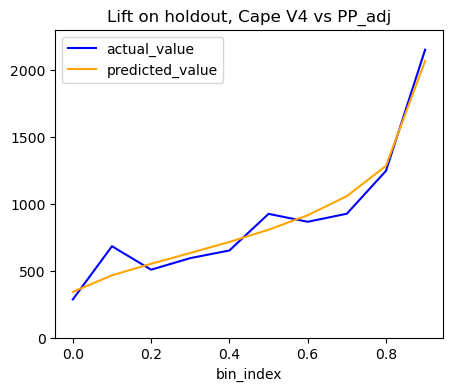

In [10]:
## V4 lift chart               
fig = plt.figure(figsize = (5, 4))
ax0 = fig.add_subplot()
# lift chart, note the underlying data for the graph will be saved in lift_chart_v and can be saved for excel use, etc.
lift_chart_v0 = km_v4.plot_weighted_lift_chart(ax = ax0, # graph handle
                                             title = 'Lift on holdout, Cape V4 vs PP_adj', # graph title
                                             ylim = (0,2300), # set appropriate ylim to display, depend on your target range 
                                             bins = 10, # large data use 100, for smaller/ noiser data, use smaller bins, e.g. 20, 10, 5, etc.
                                             )

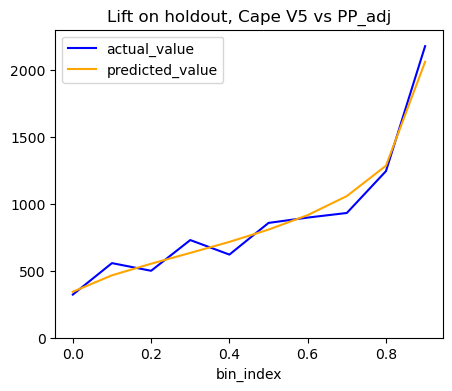

In [11]:
## V5 lift chart               

fig = plt.figure(figsize = (5, 4))
ax0 = fig.add_subplot()
# lift chart, note the underlying data for the graph will be saved in lift_chart_v and can be saved for excel use, etc.
lift_chart_v0 = km_v5.plot_weighted_lift_chart(ax = ax0, # graph handle
                                             title = 'Lift on holdout, Cape V5 vs PP_adj', # graph title
                                             ylim = (0,2300), # set appropriate ylim to display, depend on your target range 
                                             bins = 10, # large data use 100, for smaller/ noiser data, use smaller bins, e.g. 20, 10, 5, etc.
                                             )

--- Weighted ROC AUC Results ---
Cape V5 ('pp_v5'): 0.5864
Cape V4 ('pp_v4'): 0.5859
----------------------------------
y1 is  [1.19132884 0.91388524 1.04517256 0.97146319 0.9590374  0.80580064
 0.82108704 0.9220186  1.14195949 0.79110921 1.09537109 1.16556566
 1.06754386 1.03349454 0.87582518 1.43163806 0.95112167 1.10048936
 1.24855535 0.91945485]
y0 is  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
y2 is  [1.6432947  1.08496606 1.18628572 1.07096743 1.03444735 0.85319614
 0.85519632 0.9456465  1.15447782 0.78880869 1.07809342 1.13311417
 1.02520112 0.98002563 0.81899369 1.31805763 0.85958479 0.97164231
 1.06678366 0.70780164]

--- Binned Calibration Metrics (from chart) ---
             Cape V5 ('pp_v5')
  MAE (Avg. Miscalibration): 2.5903

             Cape V4 ('pp_v4')
  MAE (Avg. Miscalibration): 3.0148
---------------------------------------------


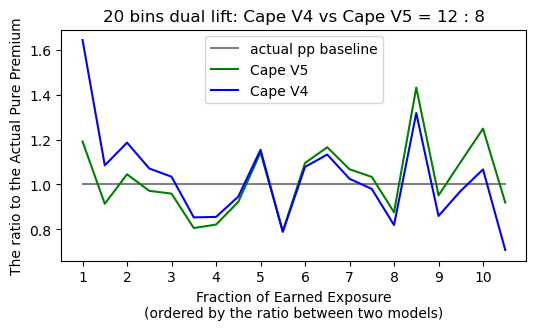

In [20]:
df_dlift = dual_lift(df_dual = df_dual,  
                        col_pp_act = 'pp_actual', 
                        col_pp_pred1 = 'pp_v5', 
                        col_pp_pred2 = 'pp_v4',  
                        col_ee = 'ee_v',  
                        n_bins =20,   
                        label1 = 'Cape V5',  
                        label2 = 'Cape V4',  
                        ) 

--- Weighted ROC AUC Results ---
base ('base'): 0.5817
Cape V5 ('pp_v5'): 0.5864
----------------------------------
y1 is  [0.61121293 1.16338586 0.82383015 0.97188543 1.0200724  0.96283373
 1.01670019 1.05967631 0.85791518 1.10637231 1.13709212 0.90883181
 0.75015598 0.98822333 1.40388077 0.99535814 1.20395639 1.2506595
 1.15603773 1.25878826]
y0 is  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
y2 is  [0.84936318 1.38173185 0.92728464 1.06131642 1.09449699 1.01914614
 1.06094725 1.08878547 0.86650718 1.09870984 1.11318712 0.87801414
 0.71572335 0.93195731 1.30793716 0.91326675 1.07633316 1.07461634
 0.95821016 0.98478256]

--- Binned Calibration Metrics (from chart) ---
             base ('base')
  MAE (Avg. Miscalibration): 2.9064

             Cape V5 ('pp_v5')
  MAE (Avg. Miscalibration): 2.3521
---------------------------------------------


<Figure size 500x400 with 0 Axes>

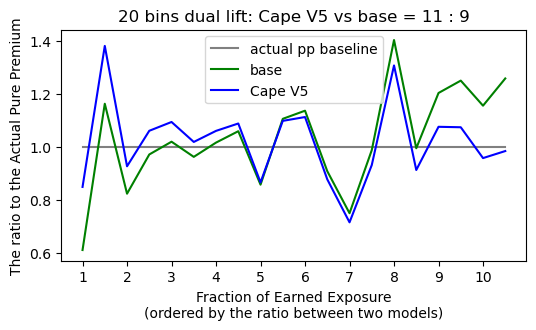

In [13]:
fig = plt.figure(figsize = (5, 4))
# ax0 = fig.add_subplot()
df_dlift = dual_lift(df_dual = df_dual,  
                        col_pp_act = 'pp_actual', 
                        col_pp_pred1 = 'base', 
                        col_pp_pred2 = 'pp_v5',  
                        col_ee = 'ee_v',  
                        n_bins =20,   
                        label1 = 'base',  
                        label2 = 'Cape V5',  
                        ) 

--- Weighted ROC AUC Results ---
base ('base'): 0.5817
Cape V4 ('pp_v4'): 0.5859
----------------------------------
y1 is  [0.96095731 0.93788698 1.20921464 0.99835878 0.91299631 1.08715534
 0.89386195 0.84204574 0.86734545 0.65601922 1.05335193 0.92732484
 0.91532952 1.04393152 1.05488801 1.60573942 1.13174204 1.22467449
 1.20922839 1.267834  ]
y0 is  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
y2 is  [1.39261043 1.10250691 1.34430292 1.07574571 0.96408548 1.13139477
 0.92018385 0.85890222 0.87709276 0.65761591 1.04609553 0.91091717
 0.88650495 0.99347195 0.98565496 1.46337085 1.0033757  1.04307365
 0.99206042 0.99995001]

--- Binned Calibration Metrics (from chart) ---
             base ('base')
  MAE (Avg. Miscalibration): 2.9756

             Cape V4 ('pp_v4')
  MAE (Avg. Miscalibration): 2.5560
---------------------------------------------


<Figure size 500x400 with 0 Axes>

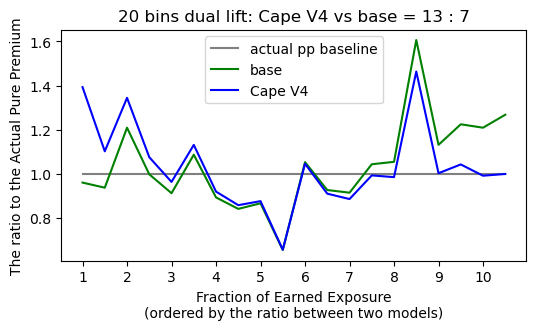

In [14]:
fig = plt.figure(figsize = (5, 4))
df_dlift = dual_lift(df_dual = df_dual,  
                        col_pp_act = 'pp_actual', 
                        col_pp_pred1 = 'base', 
                        col_pp_pred2 = 'pp_v4',  
                        col_ee = 'ee_v',  
                        n_bins =20,   
                        label1 = 'base',  
                        label2 = 'Cape V4',  
                        ) 